Visualizing Row 3376:
Low: ./images/low/000000268729.jpg
High: ./images/high/000000268729.jpg
Label: ./labels/000000268729.txt


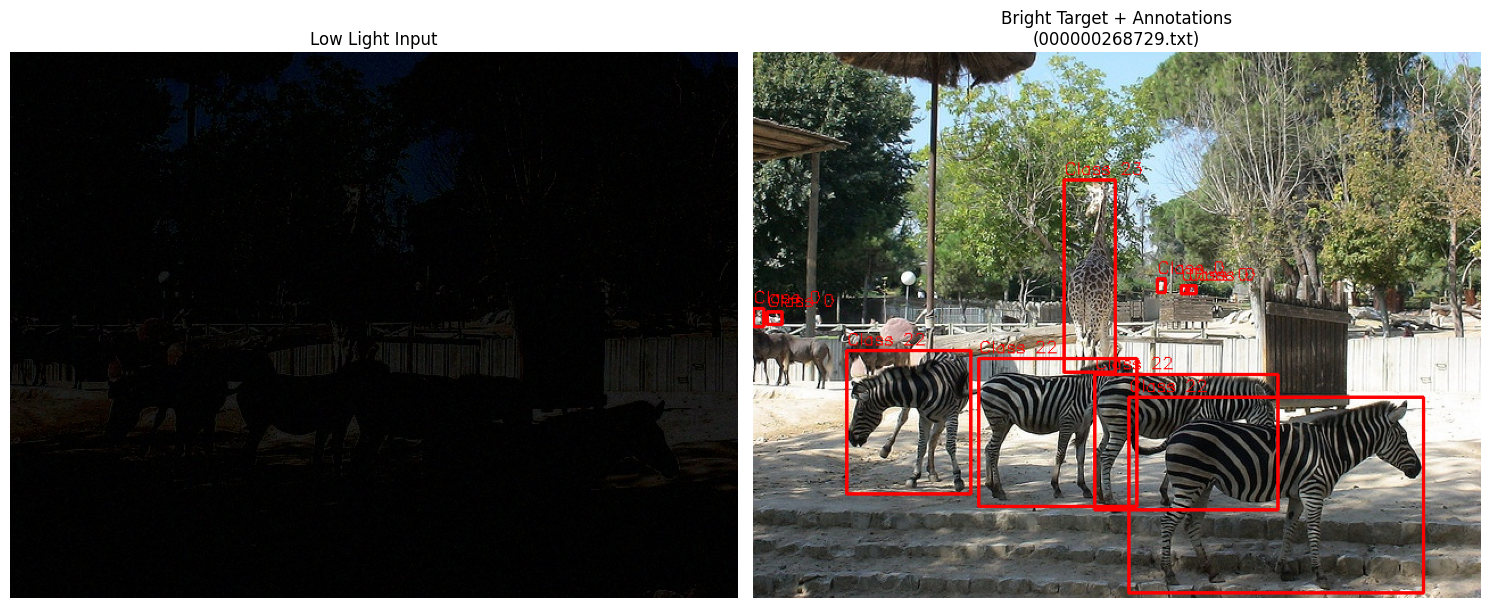

In [12]:
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import os
import random

# --- CONFIGURATION ---
csv_file_path = r'C:\Users\Sistem Cerdas Five\Desktop\vian\afre\IllumiNet-Joint-Perception\datasets\coco_mini_dark\train_metadata.csv'  # Path to your CSV
base_dataset_path = r'C:\Users\Sistem Cerdas Five\Desktop\vian\afre\IllumiNet-Joint-Perception\datasets\coco_mini_dark'         # Change this if your CSV paths are relative to a specific folder

def plot_random_row(csv_path):
    # 1. Load CSV
    df = pd.read_csv(csv_path)
    
    # 2. Select a Random Row
    if len(df) == 0:
        print("Error: CSV is empty!")
        return
        
    random_idx = random.randint(0, len(df) - 1)
    row = df.iloc[random_idx]
    
    print(f"Visualizing Row {random_idx}:")
    print(f"Low: {row['image_low']}")
    print(f"High: {row['image_high']}")
    print(f"Label: {row['label']}")

    # 3. Helper to clean paths (Handle the './' prefix)
    def clean_path(p):
        if p.startswith('./'):
            p = p[2:] # Remove './'
        return os.path.join(base_dataset_path, p)

    path_low = clean_path(row['image_low'])
    path_high = clean_path(row['image_high'])
    path_label = clean_path(row['label'])

    # 4. Load Images (OpenCV loads as BGR, convert to RGB)
    if not os.path.exists(path_low) or not os.path.exists(path_high):
        print(f"Error: Images not found at {path_low} or {path_high}")
        return

    img_low = cv2.imread(path_low)
    img_high = cv2.imread(path_high)
    
    # Convert BGR -> RGB for Matplotlib
    img_low_rgb = cv2.cvtColor(img_low, cv2.COLOR_BGR2RGB)
    img_high_rgb = cv2.cvtColor(img_high, cv2.COLOR_BGR2RGB)
    
    # 5. Draw Annotations on the High Image
    # Copy image so we don't modify the original variable
    img_annotated = img_high_rgb.copy()
    img_h, img_w, _ = img_annotated.shape

    if os.path.exists(path_label):
        with open(path_label, 'r') as f:
            lines = f.readlines()
            
        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 5:
                # Parse YOLO format: class x_center y_center width height
                cls_id = int(parts[0])
                nx, ny, nw, nh = map(float, parts[1:5])

                # Convert Normalized (0-1) to Pixels
                x1 = int((nx - nw / 2) * img_w)
                y1 = int((ny - nh / 2) * img_h)
                x2 = int((nx + nw / 2) * img_w)
                y2 = int((ny + nh / 2) * img_h)

                # Draw Rectangle (Color: Red, Thickness: 2)
                cv2.rectangle(img_annotated, (x1, y1), (x2, y2), (255, 0, 0), 2)
                
                # Optional: Add Label Text
                label_text = f"Class {cls_id}"
                cv2.putText(img_annotated, label_text, (x1, y1 - 5), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
    else:
        print(f"Warning: Label file not found at {path_label}")

    # 6. Plotting
    fig, axes = plt.subplots(1, 2, figsize=(15, 8))

    # Left Plot: Low Light
    axes[0].imshow(img_low_rgb)
    axes[0].set_title("Low Light Input")
    axes[0].axis('off')

    # Right Plot: High Light + Annotations
    axes[1].imshow(img_annotated)
    axes[1].set_title(f"Bright Target + Annotations\n({os.path.basename(path_label)})")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_random_row(csv_file_path)